# Stage-1 Curriculum Data Preparation

## What This Notebook Does
This notebook prepares representative samples for the first curriculum-training stage.

Workflow:
1. Each penetration trajectory is represented by four fitted log-parameters (`log_k_sqrt`, `log_k_quarter`, `log_t0`, `log_s`).
2. At a fixed comparison time (`5 ms`), we evaluate the penetration value for each candidate trajectory.
3. For each injector under each working condition, we keep the row of data where its penetration is the closest to the group median.

The selected rows are then used to build a stable Stage-1 training set.

## Terminology
- **Median representative row**: a typical row in the middle of the group's behavior.
- **Decompression**: reconstructing a full time series from the four fitted constants.
- **Stage-1 objective**: learn stable mean trend first; keep variance head compatible for later Neative Log Likelyhood (NLL) training, which learns the heterosedastic variances in penetration.


In [204]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Iterable, Tuple
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [205]:
# Raw datasets from image processing. We do not consider them for now. 
roots_raw = {
    "Nozzle 1"  :   r"C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py\BC20241003_HZ_Nozzle1",
    "Nozzle 2"  :   r"C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py\BC20241017_HZ_Nozzle2",
    "Nozzle 3"  :   r"C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py\BC20241014_HZ_Nozzle3",
    "Nozzle 4"  :   r"C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py\BC20241007_HZ_Nozzle4",
    "Nozzle 5"  :   r"C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py\BC20241010_HZ_Nozzle5",
    "Nozzle 6"  :   r"C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py\BC20241011_HZ_Nozzle6",
    "Nozzle 7"  :   r"C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py\BC20241015_HZ_Nozzle7",
    "Nozzle 8"  :   r"C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py\BC20241016_HZ_Nozzle8",
    "DS300"     :   r"C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py\BC20220627 - Heinzman DS300 - Mie Top view"
}



## 1) Data Source and Scope

This notebook uses fitted CSV outputs from `MLP/synthetic_data/*/clean/*.csv`,
not raw frame-by-frame image-processing results.

Benefits:
- Smaller and cleaner dataset for first-stage model validation.
- Uniform parametric representation for all trajectories.


In [206]:
# -----------------------------------------------------------------------------
# Data entry setup
# - root_extrapolated: 
#       output directory from fit_raw_data.py (each trajectory is compressed into 4 constants)
# - comparison_time_s: 
#       the reference timestamp used to select median-representative rows

#   We use *5 ms* because early transient points are noisier; far-time comparison is far more stable 
#   for selecting the most "average" representavive penetration time-series.
# -----------------------------------------------------------------------------

root_extrapolated = r"C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\synthetic_data"

# Comparison timestamp for median selection.
# You can tune this later (for example, curriculum stage-dependent).
comparison_time_s = 5e-3  # 5 ms

FPS = 25000
FPS_DS300 = 34000
root_extrapolated = Path(root_extrapolated)

In [207]:
# =============================================================================
# Utility Functions
# =============================================================================

def iter_files(directory: Path, suffix: str = None, keyword_match: str = None) -> Iterable[Path]:
    """Iterate files filtered by extension/suffix and optional filename keyword."""
    if not directory.exists():
        return []
    files = sorted(p for p in directory.iterdir() if p.is_file())
    if suffix:
        token = suffix.lower()
        if token.startswith("."):
            files = [f for f in files if f.suffix.lower() == token]
        else:
            files = [f for f in files if f.name.lower().endswith(token)]
    if keyword_match:
        key = keyword_match.lower()
        files = [f for f in files if key in f.name.lower()]
    return files

1D spray model used for curve fitting: 
$$
S(t) = (1 - w(t))\cdot k_{\text{sqrt}} \sqrt{t} + w(t)  k_{\text{quarter}} \cdot t^{1/4}
$$

$$
w(t) = \sigma\!\left(
\frac{t - t_0}{s}
\right) = 
\frac{1}{1+e^{-
\frac{t - t_b}{s}}}
$$

Physically, it does not compute any physical dependency on any input parameters. We do not intend to explore their depencies here, and they would be scaled anyways.

In [208]:
# Stuff copied from fit_raw_data
from scipy.special import expit

MIN_TI = 0.0

def spray_penetration_model_sigmoid(params, t):
    """
    params (log-space): [log_k_sqrt, log_k_quarter, log_t0, log_s]
    """
    log_k_sqrt, log_k_quarter, log_t0, log_s = params

    k_sqrt = np.exp(log_k_sqrt)
    k_quarter = np.exp(log_k_quarter)
    t0 = np.exp(log_t0) + MIN_TI
    s = np.exp(log_s)

    t = np.clip(np.asarray(t, dtype=float), 1e-9, None)
    sqrt_segment = k_sqrt * np.sqrt(t)
    quarter_root_segment = k_quarter * np.power(t, 0.25)
    w = expit((t - t0) / s)

    return (1.0 - w) * sqrt_segment + w * quarter_root_segment


In [209]:
# Get all folders containing cleaned fitted constants.
clean_data_folders = []

for experiment_dir in root_extrapolated.iterdir():
    if not experiment_dir.is_dir():
        continue

    clean_dir = experiment_dir / "clean"
    if clean_dir.is_dir():
        clean_data_folders.append(clean_dir)

## 2) Representative Row Selection Logic

For each group:
1. Compute penetration at `comparison_time_s` for every candidate row.
2. Compute the group median penetration at that same time.
3. Select the row with minimum absolute distance to that median.

This reduces sensitivity to extreme outliers and gives a robust Stage-1 seed set.


In [210]:
# -----------------------------------------------------------------------------
# Key functions:
# 1) reconstruct_penetration_series:
#    Reconstruct penetration values on any time grid from the 4 fitted log-parameters.
# 2) select_row_closest_to_median_penetration:
#    In one group, evaluate penetration at compare_time_s for all rows,
#    then select the row closest to the group median.
# -----------------------------------------------------------------------------

def reconstruct_penetration_series(
    log_k_sqrt: float,
    log_k_quarter: float,
    log_t0: float,
    log_s: float,
    time_s: np.ndarray,
) -> np.ndarray:
    """Reconstruct (decompress) penetration values on any custom time grid."""
    params = [log_k_sqrt, log_k_quarter, log_t0, log_s]
    return spray_penetration_model_sigmoid(params, time_s)


def select_row_closest_to_median_penetration(
    clean_folder: Path,
    csv_path: Path,
    fitted_df: pd.DataFrame,
    compare_time_s: float,
) -> dict:
    """Select the row whose penetration at compare_time_s is closest to file median."""
    if fitted_df.empty:
        return None

    required_cols = ["log_k_sqrt", "log_k_quarter", "log_t0", "log_s"]
    if any(col not in fitted_df.columns for col in required_cols):
        return None

    log_k_sqrt = pd.to_numeric(fitted_df["log_k_sqrt"], errors="coerce").to_numpy()
    log_k_quarter = pd.to_numeric(fitted_df["log_k_quarter"], errors="coerce").to_numpy()
    log_t0 = pd.to_numeric(fitted_df["log_t0"], errors="coerce").to_numpy()
    log_s = pd.to_numeric(fitted_df["log_s"], errors="coerce").to_numpy()

    # Vectorized evaluation of penetration at the comparison timestamp.
    penetrations_at_compare_time = spray_penetration_model_sigmoid(
        [log_k_sqrt, log_k_quarter, log_t0, log_s],
        compare_time_s,
    )

    if not np.isfinite(penetrations_at_compare_time).any():
        return None

    median_penetration = np.nanmedian(penetrations_at_compare_time)
    closest_idx = int(np.nanargmin(np.abs(penetrations_at_compare_time - median_penetration)))

    selected_row = fitted_df.iloc[closest_idx].to_dict()
    selected_row["source_file"] = str(csv_path)
    selected_row["source_folder"] = str(clean_folder)
    selected_row["comparison_time_s"] = compare_time_s
    selected_row["penetration_at_comparison_time"] = penetrations_at_compare_time[closest_idx]
    selected_row["median_penetration_in_group"] = median_penetration
    return selected_row

In [211]:
# -----------------------------------------------------------------------------
# Traverse all clean files and collect selected_rows.
# Special handling for DS300: one CSV may contain multiple injection_duration_us groups,
# so we first group by injection_duration_us and select one representative row per subgroup.
# -----------------------------------------------------------------------------

selected_rows = []
DS300_EXPERIMENT_NAME = "BC20220627 - Heinzman DS300 - Mie Top view"

for clean_folder in clean_data_folders:
    csv_files = iter_files(clean_folder, suffix=".csv")
    is_ds300 = clean_folder.parts[-2] == DS300_EXPERIMENT_NAME

    for csv_path in csv_files:
        fitted_df = pd.read_csv(csv_path)

        if is_ds300 and "injection_duration_us" in fitted_df.columns:
            grouped_frames = [group.copy() for _, group in fitted_df.groupby("injection_duration_us", dropna=False)]
        else:
            grouped_frames = [fitted_df]

        for group_df in grouped_frames:
            selected_row = select_row_closest_to_median_penetration(
                clean_folder=clean_folder,
                csv_path=csv_path,
                fitted_df=group_df,
                compare_time_s=comparison_time_s,
            )
            if selected_row is not None:
                selected_rows.append(selected_row)

In [212]:
# Optional sanity check
print("Current number of penetration time-series: ", len(selected_rows))

Current number of penetration time-series:  589


In [213]:
# -----------------------------------------------------------------------------
# df_median_seed:
# Core Stage-1 table where each row is a representative fitted trajectory plus metadata.
# This table is the input for feature engineering, scaling, and DataLoader construction.
# -----------------------------------------------------------------------------

df_median_seed = pd.DataFrame(selected_rows).reset_index(drop=True)
df_median_seed.head()

,file_path,file_name,file_stem,plume_idx,delay_frames,delay_frames_raw,delay_frames_used,k_sqrt,k_quarter,t0,...,z_t0,z_rmse,z_cost,mask_outlier,flag_bad_fit,source_file,source_folder,comparison_time_s,penetration_at_comparison_time,median_penetration_in_group
0,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,1,17.0,17.0,17.0,1.638176e-06,194.543068,0.000112,...,-0.737153,-1.121428,-0.846922,False,False,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,0.005,51.731880,51.776179
1,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,9.csv,9,2,18.0,18.0,18.0,7.932177e-07,229.333487,0.000113,...,-0.739760,-0.666053,-0.668182,False,False,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,0.005,60.983167,60.983167
2,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,15.csv,15,6,18.0,18.0,18.0,1.810355e-06,349.488228,0.000149,...,-0.506593,-0.090610,-0.115383,False,False,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,0.005,92.934090,92.934090
3,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,16.csv,16,9,16.0,16.0,16.0,9.074263e-07,390.188035,0.000216,...,1.641169,-0.687602,-0.663166,False,False,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,0.005,103.756771,104.008883
4,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,21.csv,21,5,18.0,18.0,18.0,1.166751e+01,430.371219,0.000166,...,-0.575097,-0.888960,-0.876136,False,False,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,0.005,114.442075,114.442075


## Neural Network Configuration (Presentation View)

This configuration is designed to stay compatible with later stages.

- Input: 9 physically scaled features (time, geometry, and operating conditions).
- Output: 2 heads
  - Head 1: penetration mean `mu`
  - Head 2: `log_var` reserved for later heteroscedastic NLL

At Stage-1, variance supervision is intentionally weak because only representative median trajectories are used. Only outputs from head 1 remain useful after training.


In [255]:
# -----------------------------------------------------------------------------
# Global network configuration (reproducible setup)
# Notes:
# - feature_columns is fixed to 9 physically scaled inputs
# - output_dim = 2 (mean head + log-variance head)
# - n_points controls how many decoded time samples are used per representative curve
# -----------------------------------------------------------------------------

import torch
from pathlib import Path

# Configuration (self-contained so this cell can run directly)
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data_penetration"
RUNS_ROOT = PROJECT_ROOT / "runs_mlp"

TARGET_COLUMN = "penetration_pixels"
FEATURE_COLUMNS = [
    "time_norm_0_5ms",
    "tilt_angle_radian_z",
    "plumes_z",
    "diameter_mm_z",
    "injection_duration_us_z",
    "log_injection_pressure_bar_z",
    "log_chamber_pressure_bar_z",
    "log_delta_pressure_bar_z",
    "control_backpressure_bar_z",
]
TIME_FEATURE = "time_norm_0_5ms"

CONFIG = {
    "seed": 42,
    "data_dir": str(DATA_DIR),
    "target_column": TARGET_COLUMN,
    "feature_columns": FEATURE_COLUMNS,
    "time_feature": TIME_FEATURE,
    "splits": {"val": 0.15, "test": 0.15},
    "batch_size": 256,  # number of curves per batch (before point-wise flatten)
    "hidden_dims": [512, 512, 128], 
    "dropout": 0.8,
    "activation": "gelu",
    "learning_rate": 4e-3,
    "weight_decay": 2e-4,
    "num_workers": 0,
    "pin_memory": torch.cuda.is_available(),
    "shuffle_train": True,
    "epochs": 750,
    "grad_clip_norm": 1.0,
    "log_interval": 50,
    "log_var_bounds": (-10.0, 6.0),
    "std_clamp_min": 1e-3,
    "runs_root": str(RUNS_ROOT.resolve()),
    "n_points": 1024,
    "early_stopping_patience": 50,
    "early_stopping_min_delta": 1e-5,
    "var_reg_weight": 1e-3,
    "d1_positive_weight": 5e-5,
    "d2_concave_weight": 5e-4,
    "d2_start_ms": 0.9,
    "d2_transition_ms": 0.05,
}
CONFIG["use_coordinate_descent"] = False
CONFIG["physics"] = {
    "weight": 0.0,  # stage-1 currently uses supervised loss only
    "input_map": {
        "time": "time_norm_0_5ms",
        "delta_p": "log_delta_pressure_bar_z",
        "rho_f": None,
        "rho_a": None,
        "diameter": "diameter_mm_z",
    },
    "constants": {
        "rho_f": 830.0,
        "rho_a": 1.225,
    },
    "unit_scales": {
        "time": 1.0,
        "diameter": 1.0,
    },
    "init_params": {
        "kv": 0.9,
        "kp": 0.6,
        "tau": 0.15,
    },
    "min_tau": 1e-4,
}
CONFIG["hyperparameter_space"] = {
    "lr": [1e-4, 3e-4, 1e-3],
    "weight_decay": [1e-5, 1e-4, 1e-3, 1e-2],
    "epochs": [40, 60, 80],
}
CONFIG["hyperparameter_tolerance"] = 1e-4
CONFIG["input_dim"] = len(CONFIG["feature_columns"])
CONFIG["output_dim"] = 2
CONFIG["device"] = "cuda" if torch.cuda.is_available() else "cpu"
CONFIG["log_epoch_finish"] = True

torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

print(f"Config ready. device={CONFIG['device']}, input_dim={CONFIG['input_dim']}, n_points={CONFIG['n_points']}")

Config ready. device=cuda, input_dim=9, n_points=1024


In [256]:
from torch import nn

# MLP architecture

def make_activation(name: str) -> nn.Module:
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "tanh":
        return nn.Tanh()
    raise ValueError(f"Unsupported activation '{name}'")


class PenetrationMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        output_dim: int,
        *,
        activation: str = "relu",
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        layers: list[nn.Module] = []
        in_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend(
                [
                    nn.Linear(in_dim, hidden_dim),
                    nn.LayerNorm(hidden_dim),
                    make_activation(activation),
                ]
            )
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def build_model(config: dict) -> PenetrationMLP:
    return PenetrationMLP(
        input_dim=config["input_dim"],
        hidden_dims=config["hidden_dims"],
        output_dim=config["output_dim"],
        activation=config["activation"],
        dropout=config["dropout"],
    ).to(config["device"])

## 3) Physically Consistent Scaling Strategy

Reason:
- If we don't scale the input parameters/feautures, when we do gradient descent then update the weights, we find the optimum at this stage a very flat ellipse instead of a circle, which makes learning difficult and numerically unstable, also preventing learning biases towards some variables.
- Example: Injection pressure: 1400-2200 (bar), nozzle diameter: 0.3-0.4 (mm), chamber pressure: 5-35 (bar)

Goal:
- Preserve physical relationships.
- Prevent training imbalance due to mixed units and large magnitude gaps.

Chosen strategy:
- Time: fixed min-max over `0~5 ms`.
- Pressure: $$log(P_{inj}), log(P_{ch})$$ , and $$log(P_{inj}-P_{ch})$$.
- Geometry/condition terms (`tilt`, `plumes`, `diameter`, `duration`, `control_backpressure`): z-score (value -avg then /std of the dataset)
- Missing pressure: filled with 2000 bar default.
- Missing backpressure: filled with 4 bar default.


In [257]:
# -----------------------------------------------------------------------------
# Stage-1 feature engineering pipeline:
# A. Canonicalize physical columns and apply default fill values (Pinj=2000 bar, control_backpressure=4 bar)
# B. Convert umbrella angle to tilt_angle_radian by experiment/nozzle mapping
# C. Build pressure-derived terms: Pinj, Pch, deltaP, log(Pinj), log(Pch), log(deltaP)
# D. Fit z-score parameters on train split only and store them in scaler_state for inference reuse
# -----------------------------------------------------------------------------

if "df_collection" not in globals():
    df_collection = df_median_seed.copy()

FILL_DEFAULTS = {
    "injection_pressure_bar": 2000.0,
    "control_backpressure_bar": 4.0,
}

# Umbrella-angle mapping by experiment name in source path.
# tilt = (180 - umbrella)/2 [deg], then converted to radian.
UMBRELLA_ANGLE_BY_EXPERIMENT = {
    "nozzle1": 140.0,
    "nozzle2": 140.0,
    "nozzle3": 140.0,
    "nozzle4": 140.0,
    "nozzle5": 140.0,
    "nozzle6": 140.0,
    "nozzle7": 164.0,
    "nozzle8": 130.0,
    "ds300": 140.0,
}


def _infer_umbrella_angle_deg(source_folder: str) -> float:
    text = str(source_folder).lower()
    for key, umbrella in UMBRELLA_ANGLE_BY_EXPERIMENT.items():
        if key in text:
            return float(umbrella)
    return 140.0


def _to_numeric_required(df: pd.DataFrame, col: str) -> pd.Series:
    if col not in df.columns:
        raise KeyError(f"Required column '{col}' is missing from df_collection")
    out = pd.to_numeric(df[col], errors="coerce")
    if out.isna().any():
        raise ValueError(f"Column '{col}' contains NaN after numeric coercion")
    return out.astype(float)


def build_row_level_feature_table(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy().reset_index(drop=True)

    # Canonical numeric columns
    df["chamber_pressure_bar"] = _to_numeric_required(df, "chamber_pressure_bar")
    df["injection_duration_us"] = _to_numeric_required(df, "injection_duration_us")
    df["diameter_mm"] = _to_numeric_required(df, "diameter_mm")
    df["plumes"] = _to_numeric_required(df, "plumes")

    inj_raw = pd.to_numeric(df.get("injection_pressure_bar", pd.Series(np.nan, index=df.index)), errors="coerce")
    df["injection_pressure_bar"] = inj_raw.fillna(FILL_DEFAULTS["injection_pressure_bar"]).astype(float)

    cb_raw = pd.to_numeric(df.get("control_backpressure_bar", pd.Series(np.nan, index=df.index)), errors="coerce")
    df["control_backpressure_bar"] = cb_raw.fillna(FILL_DEFAULTS["control_backpressure_bar"]).astype(float)

    # Build tilt in radian from source folder -> umbrella angle map.
    source_series = df.get("source_folder", pd.Series([""] * len(df), index=df.index)).astype(str)
    umbrella_deg = source_series.map(_infer_umbrella_angle_deg).astype(float)
    tilt_deg = (180.0 - umbrella_deg) / 2.0
    df["tilt_angle_radian"] = np.deg2rad(tilt_deg)

    # Pressure-derived features in log domain.
    p_inj = df["injection_pressure_bar"].to_numpy(dtype=float)
    p_ch = df["chamber_pressure_bar"].to_numpy(dtype=float)
    delta_p = np.maximum(p_inj - p_ch, 1e-6)

    df["delta_pressure_bar"] = delta_p
    df["log_injection_pressure_bar"] = np.log(p_inj)
    df["log_chamber_pressure_bar"] = np.log(np.maximum(p_ch, 1e-6))
    df["log_delta_pressure_bar"] = np.log(delta_p)

    return df


def train_val_test_split(
    n_samples: int,
    val_ratio: float,
    test_ratio: float,
    *,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if not 0 < val_ratio < 1 or not 0 < test_ratio < 1:
        raise ValueError("Validation and test ratios must be in (0, 1).")
    if val_ratio + test_ratio >= 1:
        raise ValueError("Sum of validation and test ratios must be < 1.")

    rng = np.random.default_rng(seed)
    indices = np.arange(n_samples)
    rng.shuffle(indices)

    n_test = int(np.floor(test_ratio * n_samples))
    n_val = int(np.floor(val_ratio * n_samples))

    test_idx = indices[:n_test]
    val_idx = indices[n_test : n_test + n_val]
    train_idx = indices[n_test + n_val :]
    return train_idx, val_idx, test_idx


def fit_zscore_params(train_df: pd.DataFrame, cols: list[str], eps: float = 1e-8) -> dict[str, dict[str, float]]:
    params: dict[str, dict[str, float]] = {}
    for col in cols:
        s = pd.to_numeric(train_df[col], errors="coerce").astype(float)
        mean = float(np.nanmean(s))
        std = float(np.nanstd(s))
        if (not np.isfinite(std)) or std < eps:
            std = 1.0
        params[col] = {"mean": mean, "std": std}
    return params


def apply_zscore(df: pd.DataFrame, params: dict[str, dict[str, float]]) -> pd.DataFrame:
    out = df.copy()
    for base_col, p in params.items():
        out[f"{base_col}_z"] = (pd.to_numeric(out[base_col], errors="coerce") - p["mean"]) / (p["std"] + 1e-12)
    return out


# 1) Build row-level feature table.
df_stage1_rows = build_row_level_feature_table(df_collection)

# 2) Split rows (fit scalers only on train rows).
split_cfg = CONFIG["splits"]
train_idx, val_idx, test_idx = train_val_test_split(
    len(df_stage1_rows),
    split_cfg["val"],
    split_cfg["test"],
    seed=CONFIG["seed"],
)

# 3) Fit z-score parameters on train subset.
ZSCORE_BASE_COLUMNS = [
    "tilt_angle_radian",
    "plumes",
    "diameter_mm",
    "injection_duration_us",
    "log_injection_pressure_bar",
    "log_chamber_pressure_bar",
    "log_delta_pressure_bar",
    "control_backpressure_bar",
]
zscore_params_base = fit_zscore_params(df_stage1_rows.iloc[train_idx], ZSCORE_BASE_COLUMNS)
df_stage1_rows = apply_zscore(df_stage1_rows, zscore_params_base)

# 4) Store scaler state for reproducible training/inference.
scaler_state = {
    "time": {"type": "fixed_minmax", "min_ms": 0.0, "max_ms": 5.0},
    "zscore": {f"{k}_z": v for k, v in zscore_params_base.items()},
    "fill_defaults": FILL_DEFAULTS.copy(),
}

# Split views for dataset creation.
df_stage1_train = df_stage1_rows.iloc[train_idx].reset_index(drop=True)
df_stage1_val = df_stage1_rows.iloc[val_idx].reset_index(drop=True)
df_stage1_test = df_stage1_rows.iloc[test_idx].reset_index(drop=True)

print("Stage-1 row table shape:", df_stage1_rows.shape)
print("Split sizes (train/val/test):", len(df_stage1_train), len(df_stage1_val), len(df_stage1_test))
print("Scaler state keys:", list(scaler_state.keys()))

Stage-1 row table shape: (589, 55)
Split sizes (train/val/test): 413 88 88
Scaler state keys: ['time', 'zscore', 'fill_defaults']


## DataLoader Design (Row-to-Point Expansion)

Each row in `df_stage1_*` represents one operating condition with four fitted constants.
In `__getitem__`, we:
1. Reconstruct penetration values on a fixed `0~5 ms` grid with `n_points` samples.
2. Build point-wise feature vectors by combining the same static condition features with each time point.

A batch is flattened from `[B, T, F]` to `[B*T, F]` for standard point-wise MLP training.


In [258]:
# -----------------------------------------------------------------------------
# Dataset / DataLoader design:
# - One row (one operating condition) -> one decoded 0~5 ms penetration sequence
# - Each time step uses the same static condition features + normalized time
# - Collation flattens into point-wise samples for standard MLP regression
# - Final assertions verify engineering reliability: no NaN, correct scaling, correct dimensions
# -----------------------------------------------------------------------------

import torch
from torch.utils.data import Dataset, DataLoader


class Stage1MedianPenetrationDataset(Dataset):
    """Decode one fitted row to point-wise features/targets on a fixed 0-5 ms grid."""

    STATIC_FEATURE_COLUMNS = [
        "tilt_angle_radian_z",
        "plumes_z",
        "diameter_mm_z",
        "injection_duration_us_z",
        "log_injection_pressure_bar_z",
        "log_chamber_pressure_bar_z",
        "log_delta_pressure_bar_z",
        "control_backpressure_bar_z",
    ]

    def __init__(
        self,
        df: pd.DataFrame,
        *,
        n_points: int,
        time_min_ms: float = 0.0,
        time_max_ms: float = 5.0,
    ) -> None:
        self.df = df.reset_index(drop=True).copy()
        self.n_points = int(n_points)
        self.time_min_ms = float(time_min_ms)
        self.time_max_ms = float(time_max_ms)

        self.time_grid_ms = np.linspace(self.time_min_ms, self.time_max_ms, self.n_points, dtype=np.float32)
        self.time_grid_s = self.time_grid_ms * 1e-3
        self.time_norm = np.clip(self.time_grid_ms, 0.0, 5.0) / 5.0

        missing = [c for c in self.STATIC_FEATURE_COLUMNS if c not in self.df.columns]
        if missing:
            raise KeyError(f"Missing scaled static feature columns: {missing}")

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]

        penetration = reconstruct_penetration_series(
            log_k_sqrt=float(row["log_k_sqrt"]),
            log_k_quarter=float(row["log_k_quarter"]),
            log_t0=float(row["log_t0"]),
            log_s=float(row["log_s"]),
            time_s=self.time_grid_s,
        ).astype(np.float32)

        static_vec = row[self.STATIC_FEATURE_COLUMNS].to_numpy(dtype=np.float32)
        static_mat = np.repeat(static_vec[None, :], self.n_points, axis=0)

        features = np.column_stack([self.time_norm.astype(np.float32), static_mat]).astype(np.float32)
        targets = penetration.reshape(-1, 1)

        return {
            "features": torch.from_numpy(features),
            "targets": torch.from_numpy(targets),
            "sample_idx": torch.full((self.n_points,), int(idx), dtype=torch.long),
        }


def collate_pointwise(batch: list[dict]) -> dict:
    features = torch.cat([item["features"] for item in batch], dim=0)
    targets = torch.cat([item["targets"] for item in batch], dim=0)
    sample_idx = torch.cat([item["sample_idx"] for item in batch], dim=0)
    return {"features": features, "targets": targets, "sample_idx": sample_idx}


dataset_stage1_train = Stage1MedianPenetrationDataset(
    df_stage1_train,
    n_points=CONFIG["n_points"],
    time_min_ms=scaler_state["time"]["min_ms"],
    time_max_ms=scaler_state["time"]["max_ms"],
)
dataset_stage1_val = Stage1MedianPenetrationDataset(
    df_stage1_val,
    n_points=CONFIG["n_points"],
    time_min_ms=scaler_state["time"]["min_ms"],
    time_max_ms=scaler_state["time"]["max_ms"],
)
dataset_stage1_test = Stage1MedianPenetrationDataset(
    df_stage1_test,
    n_points=CONFIG["n_points"],
    time_min_ms=scaler_state["time"]["min_ms"],
    time_max_ms=scaler_state["time"]["max_ms"],
)

dataloader_kwargs = {
    "batch_size": CONFIG["batch_size"],
    "num_workers": CONFIG["num_workers"],
    "pin_memory": CONFIG["pin_memory"],
    "collate_fn": collate_pointwise,
}

train_loader_stage1 = DataLoader(
    dataset_stage1_train,
    shuffle=CONFIG["shuffle_train"],
    **dataloader_kwargs,
)
val_loader_stage1 = DataLoader(dataset_stage1_val, shuffle=False, **dataloader_kwargs)
test_loader_stage1 = DataLoader(dataset_stage1_test, shuffle=False, **dataloader_kwargs)

first_batch = next(iter(train_loader_stage1))
print("feature batch shape:", tuple(first_batch["features"].shape))
print("target batch shape:", tuple(first_batch["targets"].shape))
print("sample_idx shape:", tuple(first_batch["sample_idx"].shape))
print("feature_dim from batch:", first_batch["features"].shape[1], "expected:", len(FEATURE_COLUMNS))

# -------------------------------------------------------------------------
# Acceptance checks from the plan
# -------------------------------------------------------------------------
required_numeric_cols = [
    "injection_pressure_bar",
    "control_backpressure_bar",
    "delta_pressure_bar",
    "log_delta_pressure_bar",
] + Stage1MedianPenetrationDataset.STATIC_FEATURE_COLUMNS

assert np.isfinite(df_stage1_rows[required_numeric_cols].to_numpy(dtype=float)).all(), "NaN/Inf found in engineered features"
assert (df_stage1_rows["delta_pressure_bar"] > 0).all(), "delta_p must be > 0"
assert np.isfinite(df_stage1_rows["log_delta_pressure_bar"]).all(), "log_delta_p contains non-finite values"

# Time normalization check in the first batch
assert torch.all(first_batch["features"][:, 0] >= 0.0) and torch.all(first_batch["features"][:, 0] <= 1.0), "time_norm_0_5ms must be in [0,1]"

# Z-score check on train rows (non-constant original columns should have std~1)
for base_col in ZSCORE_BASE_COLUMNS:
    z_col = f"{base_col}_z"
    raw_std = np.nanstd(df_stage1_train[base_col].to_numpy(dtype=float))
    z_mean = float(np.nanmean(df_stage1_train[z_col].to_numpy(dtype=float)))
    z_std = float(np.nanstd(df_stage1_train[z_col].to_numpy(dtype=float)))
    assert abs(z_mean) < 1e-6, f"{z_col} mean is not near 0"
    if raw_std >= 1e-8:
        assert abs(z_std - 1.0) < 1e-3, f"{z_col} std is not near 1"

assert first_batch["features"].shape[1] == 9, "Feature dimension must be 9"
print("All stage-1 data checks passed.")

feature batch shape: (262144, 9)
target batch shape: (262144, 1)
sample_idx shape: (262144,)
feature_dim from batch: 9 expected: 9
All stage-1 data checks passed.


## 4) No-Plot Validation Checklist

- Data integrity: no `NaN/Inf` in training features.
- Physical consistency: `deltaP > 0`, and `log(deltaP)` finite.
- Scaling correctness: time in `[0,1]`; z-score columns normalized on train split.
- Interface consistency: input dimension is `9`; model output dimension is `2`.


## Regularization Techniques Used So Far

This Stage-1 pipeline uses several regularization mechanisms to improve robustness and physical consistency:

1. **Dropout (`CONFIG["dropout"]`)**  
   Randomly drops hidden activations during training to reduce co-adaptation and overfitting.

2. **Weight decay (AdamW `weight_decay`)**  
   Penalizes large weights and encourages smoother function approximation.

3. **Early stopping (`patience`, `min_delta`)**  
   Stops training when validation loss no longer improves, preventing late-stage overfitting.

4. **Variance-head regularization (`var_reg_weight`)**  
   Keeps `log_var` close to a prior during Stage-1, because representative median trajectories do not provide strong heteroscedastic supervision.

5. **First-derivative monotonicity penalty (`d1_positive_weight`)**  
   Penalizes negative slope (`dmu/dt < 0`), encouraging non-decreasing penetration with time.

6. **Second-derivative concavity penalty with delayed activation (`d2_concave_weight`)**  
   Penalizes positive curvature (`d2mu/dt2 > 0`) mainly after `t >= d2_start_ms` using a soft sigmoid gate.
   This allows physically plausible early-time acceleration and enforces decelerating growth later.


## Stage-1 Loss: Why Keep 2 Outputs but Not Full NLL Yet?

At Stage-1, we only have representative median trajectories.
That is not enough to reliably supervise heteroscedastic variance.

So we use:
- Main term: `MSE(mu, y)`
- Auxiliary term: `||log_var - prior||^2`

This keeps architecture compatibility while preventing unstable variance learning too early.


In [259]:
# -----------------------------------------------------------------------------
# Stage-1 loss:
# loss = MSE(mu, y)
#      + lambda_var * ||log_var - prior||^2
#      + lambda_d1 * penalty(dmu/dt < 0)
#      + lambda_d2 * penalty(d2mu/dt2 > 0, active mostly after t >= d2_start_ms)
# Rationale:
# - dmu/dt > 0 enforces non-decreasing penetration trend
# - d2mu/dt2 <= 0 is enforced after the early acceleration phase
# -----------------------------------------------------------------------------


def split_mu_logvar(model_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    mu, log_var = model_output.chunk(2, dim=-1)
    return mu, log_var


def _derivative_physics_penalty(
    mu: torch.Tensor,
    n_points: int,
    *,
    time_max_ms: float,
    d2_start_ms: float,
    d2_transition_ms: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Return penalties for dmu/dt > 0 and soft-gated d2mu/dt2 <= 0 constraints."""
    if n_points <= 1:
        zero = mu.new_tensor(0.0)
        return zero, zero

    # [B*T, 1] -> [B, T]
    mu_seq = mu.reshape(-1, n_points)

    # First difference (proportional to dmu/dt because dt is constant).
    d1 = mu_seq[:, 1:] - mu_seq[:, :-1]
    d1_negative_penalty = torch.relu(-d1).pow(2).mean()

    if n_points <= 2:
        d2_positive_penalty = mu.new_tensor(0.0)
    else:
        # Second difference (proportional to d2mu/dt2 with constant dt).
        d2 = mu_seq[:, 2:] - 2.0 * mu_seq[:, 1:-1] + mu_seq[:, :-2]

        # Build time centers for second derivative positions (t[1:-1]).
        t_ms = torch.linspace(0.0, float(time_max_ms), int(n_points), device=mu.device)
        t_center_ms = t_ms[1:-1]

        # Soft gate: near 0 before d2_start_ms, near 1 after d2_start_ms.
        # This allows early-time acceleration but penalizes positive d2 later.
        gate = torch.sigmoid((t_center_ms - float(d2_start_ms)) / max(float(d2_transition_ms), 1e-6))
        gate = gate.unsqueeze(0)  # [1, T-2], broadcast over batch

        d2_positive_penalty = (torch.relu(d2).pow(2) * gate).mean()

    return d1_negative_penalty, d2_positive_penalty


def stage1_loss(
    model_output: torch.Tensor,
    target: torch.Tensor,
    *,
    n_points: int,
    time_max_ms: float = 5.0,
    d2_start_ms: float = 0.5,
    d2_transition_ms: float = 0.05,
    log_var_prior: float = -2.0,
    var_reg_weight: float = 1e-3,
    d1_positive_weight: float = 5e-5,
    d2_concave_weight: float = 5e-5,
    log_var_bounds: tuple[float, float] = (-10.0, 6.0),
) -> tuple[torch.Tensor, dict]:
    """Stage-1 objective with weak variance and physics-shape regularization."""
    mu, log_var = split_mu_logvar(model_output)
    log_var = torch.clamp(log_var, min=log_var_bounds[0], max=log_var_bounds[1])

    mse_loss = torch.mean((mu - target) ** 2)

    prior = torch.full_like(log_var, float(log_var_prior))
    var_reg = torch.mean((log_var - prior) ** 2)

    d1_penalty, d2_penalty = _derivative_physics_penalty(
        mu,
        n_points=n_points,
        time_max_ms=time_max_ms,
        d2_start_ms=d2_start_ms,
        d2_transition_ms=d2_transition_ms,
    )

    loss = (
        mse_loss
        + float(var_reg_weight) * var_reg
        + float(d1_positive_weight) * d1_penalty
        + float(d2_concave_weight) * d2_penalty
    )

    metrics = {
        "loss": float(loss.detach().cpu()),
        "mse": float(mse_loss.detach().cpu()),
        "var_reg": float(var_reg.detach().cpu()),
        "d1_penalty": float(d1_penalty.detach().cpu()),
        "d2_penalty": float(d2_penalty.detach().cpu()),
    }
    return loss, metrics


# Shape acceptance check: model output must be [batch*n_points, 2]
model = build_model(CONFIG)
model.eval()
with torch.no_grad():
    output = model(first_batch["features"].to(CONFIG["device"]))

assert output.shape == (first_batch["features"].shape[0], 2), "Model output shape must be [batch*n_points, 2]"
print("Model output shape check passed:", tuple(output.shape))

# Example loss call
loss, metrics = stage1_loss(
    output,
    first_batch["targets"].to(CONFIG["device"]),
    n_points=CONFIG["n_points"],
    time_max_ms=scaler_state["time"]["max_ms"],
    d2_start_ms=CONFIG.get("d2_start_ms", 0.5),
    d2_transition_ms=CONFIG.get("d2_transition_ms", 0.05),
    var_reg_weight=CONFIG.get("var_reg_weight", 1e-3),
    d1_positive_weight=CONFIG.get("d1_positive_weight", 5e-5),
    d2_concave_weight=CONFIG.get("d2_concave_weight", 5e-5),
)
print("Stage-1 loss example:", metrics)


Model output shape check passed: (262144, 2)
Stage-1 loss example: {'loss': 9277.9140625, 'mse': 9277.91015625, 'var_reg': 3.6590795516967773, 'd1_penalty': 2.0109014897684574e-08, 'd2_penalty': 2.228726372292128e-13}


## Stage-1 Training Loop, Loss Logging, and Plot

This section trains the Stage-1 model using `stage1_loss`, records loss for every iteration,
and plots both iteration-level and epoch-level curves.

Outputs saved under `CONFIG["runs_root"]/stage1_median_penetration_*`:
- `iteration_loss.csv`
- `epoch_loss.csv`
- `loss_curves.png`


In [260]:
import time
from datetime import datetime


def run_stage1_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    *,
    optimizer: torch.optim.Optimizer | None,
    device: str,
    global_iter_start: int,
    epoch_idx: int,
    n_points: int,
    log_every: int = 50,
) -> tuple[dict, list[dict], int]:
    """Run one epoch and return epoch metrics, per-iteration logs, and updated global iteration index."""
    is_train = optimizer is not None
    model.train(mode=is_train)

    total_loss = 0.0
    total_mse = 0.0
    total_var_reg = 0.0
    total_d1_penalty = 0.0
    total_d2_penalty = 0.0
    total_points = 0

    iter_logs: list[dict] = []
    global_iter = int(global_iter_start)

    for step_idx, batch in enumerate(dataloader, start=1):
        x = batch["features"].to(device)
        y = batch["targets"].to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        pred = model(x)
        loss, metrics = stage1_loss(
            pred,
            y,
            n_points=n_points,
            log_var_bounds=CONFIG["log_var_bounds"],
            var_reg_weight=CONFIG.get("var_reg_weight", 1e-3),
            d1_positive_weight=CONFIG.get("d1_positive_weight", 5e-5),
            d2_concave_weight=CONFIG.get("d2_concave_weight", 5e-5),
            time_max_ms=scaler_state["time"]["max_ms"],
            d2_start_ms=CONFIG.get("d2_start_ms", 0.5),
            d2_transition_ms=CONFIG.get("d2_transition_ms", 0.05),
        )

        if is_train:
            loss.backward()
            if CONFIG.get("grad_clip_norm") is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), float(CONFIG["grad_clip_norm"]))
            optimizer.step()

        n = int(x.shape[0])
        total_points += n
        total_loss += float(loss.detach().cpu()) * n
        total_mse += float(metrics["mse"]) * n
        total_var_reg += float(metrics["var_reg"]) * n
        total_d1_penalty += float(metrics["d1_penalty"]) * n
        total_d2_penalty += float(metrics["d2_penalty"]) * n

        iter_logs.append(
            {
                "epoch": epoch_idx,
                "step": step_idx,
                "global_iter": global_iter,
                "split": "train" if is_train else "val",
                "loss": float(metrics["loss"]),
                "mse": float(metrics["mse"]),
                "var_reg": float(metrics["var_reg"]),
                "d1_penalty": float(metrics["d1_penalty"]),
                "d2_penalty": float(metrics["d2_penalty"]),
                "n_points": n,
            }
        )

        if is_train and (step_idx % log_every == 0):
            print(
                f"[Epoch {epoch_idx:03d}] step={step_idx:04d} iter={global_iter:06d} "
                f"loss={metrics['loss']:.6f} mse={metrics['mse']:.6f} "
                f"d1={metrics['d1_penalty']:.3e} d2={metrics['d2_penalty']:.3e}"
            )

        global_iter += 1

    denom = max(total_points, 1)
    epoch_metrics = {
        "epoch": epoch_idx,
        "split": "train" if is_train else "val",
        "loss": total_loss / denom,
        "mse": total_mse / denom,
        "var_reg": total_var_reg / denom,
        "d1_penalty": total_d1_penalty / denom,
        "d2_penalty": total_d2_penalty / denom,
        "points": total_points,
    }
    return epoch_metrics, iter_logs, global_iter


# -------------------------------------------------------------------------
# Training config for Stage-1
# -------------------------------------------------------------------------
EPOCHS = int(CONFIG["epochs"])
LR = float(CONFIG["learning_rate"])
WEIGHT_DECAY = float(CONFIG["weight_decay"])
PATIENCE = int(CONFIG.get("early_stopping_patience", 30))
MIN_DELTA = float(CONFIG.get("early_stopping_min_delta", 1e-5))

model_stage1 = build_model(CONFIG)
optimizer_stage1 = torch.optim.AdamW(
    model_stage1.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = Path(CONFIG["runs_root"]) / f"stage1_median_penetration_{run_stamp}"
run_dir.mkdir(parents=True, exist_ok=False)

iter_history: list[dict] = []
epoch_history: list[dict] = []

best_val_loss = float("inf")
best_state = {"epoch": 0, "model_state": None, "val_loss": float("inf")}

global_iter = 0
start_t = time.time()
no_improve_count = 0

for epoch in range(1, EPOCHS + 1):
    train_metrics, train_iter_logs, global_iter = run_stage1_epoch(
        model_stage1,
        train_loader_stage1,
        optimizer=optimizer_stage1,
        device=CONFIG["device"],
        global_iter_start=global_iter,
        epoch_idx=epoch,
        n_points=int(CONFIG["n_points"]),
        log_every=max(1, int(CONFIG.get("log_interval", 50))),
    )

    with torch.no_grad():
        val_metrics, val_iter_logs, global_iter = run_stage1_epoch(
            model_stage1,
            val_loader_stage1,
            optimizer=None,
            device=CONFIG["device"],
            global_iter_start=global_iter,
            epoch_idx=epoch,
            n_points=int(CONFIG["n_points"]),
            log_every=max(1, int(CONFIG.get("log_interval", 50))),
        )

    iter_history.extend(train_iter_logs)
    iter_history.extend(val_iter_logs)
    epoch_history.append(train_metrics)
    epoch_history.append(val_metrics)

    improved = (best_val_loss - float(val_metrics["loss"])) > MIN_DELTA
    if improved:
        best_val_loss = float(val_metrics["loss"])
        best_state = {
            "epoch": epoch,
            "model_state": {k: v.detach().cpu().clone() for k, v in model_stage1.state_dict().items()},
            "val_loss": best_val_loss,
        }
        no_improve_count = 0
    else:
        no_improve_count += 1
        
    if epoch % 25 == 0:
        print(
            f"Epoch {epoch:03d}/{EPOCHS} | "
            f"train_loss={train_metrics['loss']:.6f} val_loss={val_metrics['loss']:.6f} "
            f"train_mse={train_metrics['mse']:.6f} val_mse={val_metrics['mse']:.6f} "
            f"no_improve={no_improve_count}/{PATIENCE}"
        )

    if no_improve_count >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch} (patience={PATIENCE}, min_delta={MIN_DELTA}).")
        break

elapsed = time.time() - start_t
print(f"Training finished in {elapsed:.1f}s. Best val loss={best_state['val_loss']:.6f} at epoch {best_state['epoch']}.")

# Restore best model
if best_state["model_state"] is not None:
    model_stage1.load_state_dict(best_state["model_state"])

# Evaluate on test split with the best checkpoint
model_stage1.eval()
with torch.no_grad():
    test_metrics, test_iter_logs, _ = run_stage1_epoch(
        model_stage1,
        test_loader_stage1,
        optimizer=None,
        device=CONFIG["device"],
        global_iter_start=global_iter,
        epoch_idx=best_state["epoch"],
        n_points=int(CONFIG["n_points"]),
    )
print(
    f"Test loss={test_metrics['loss']:.6f}, test mse={test_metrics['mse']:.6f}, "
    f"test d1={test_metrics['d1_penalty']:.3e}, test d2={test_metrics['d2_penalty']:.3e}"
)

# -------------------------------------------------------------------------
# Save logs and model
# -------------------------------------------------------------------------
df_iter_history = pd.DataFrame(iter_history)
df_epoch_history = pd.DataFrame(epoch_history)

df_iter_history.to_csv(run_dir / "iteration_loss.csv", index=False)
df_epoch_history.to_csv(run_dir / "epoch_loss.csv", index=False)
torch.save(model_stage1.state_dict(), run_dir / "best_model_stage1.pt")

with open(run_dir / "scaler_state.json", "w", encoding="utf-8") as f:
    import json
    json.dump(scaler_state, f, indent=2)

with open(run_dir / "train_config_used.json", "w", encoding="utf-8") as f:
    import json
    json.dump({k: v for k, v in CONFIG.items() if isinstance(v, (int, float, str, bool, list, dict))}, f, indent=2)

print("Saved files:")
print(" -", run_dir / "iteration_loss.csv")
print(" -", run_dir / "epoch_loss.csv")
print(" -", run_dir / "best_model_stage1.pt")
print(" -", run_dir / "scaler_state.json")
print(" -", run_dir / "train_config_used.json")


Epoch 025/750 | train_loss=5815.023621 val_loss=5220.245117 train_mse=5814.972214 val_mse=5220.245117 no_improve=0/50
Epoch 050/750 | train_loss=2839.617280 val_loss=2303.761963 train_mse=2839.322655 val_mse=2303.761963 no_improve=0/50
Epoch 075/750 | train_loss=1319.480807 val_loss=598.123596 train_mse=1318.671805 val_mse=598.123596 no_improve=0/50
Epoch 100/750 | train_loss=728.405692 val_loss=122.968315 train_mse=727.505896 val_mse=122.968307 no_improve=1/50
Epoch 125/750 | train_loss=621.363237 val_loss=96.400269 train_mse=620.574866 val_mse=96.400261 no_improve=1/50
Epoch 150/750 | train_loss=563.130337 val_loss=68.337776 train_mse=562.408310 val_mse=68.337769 no_improve=3/50
Epoch 175/750 | train_loss=515.546442 val_loss=49.589142 train_mse=514.895977 val_mse=49.589134 no_improve=0/50
Epoch 200/750 | train_loss=477.534681 val_loss=48.471195 train_mse=476.927246 val_mse=48.471191 no_improve=2/50
Epoch 225/750 | train_loss=449.819633 val_loss=41.452805 train_mse=449.245577 val_mse=

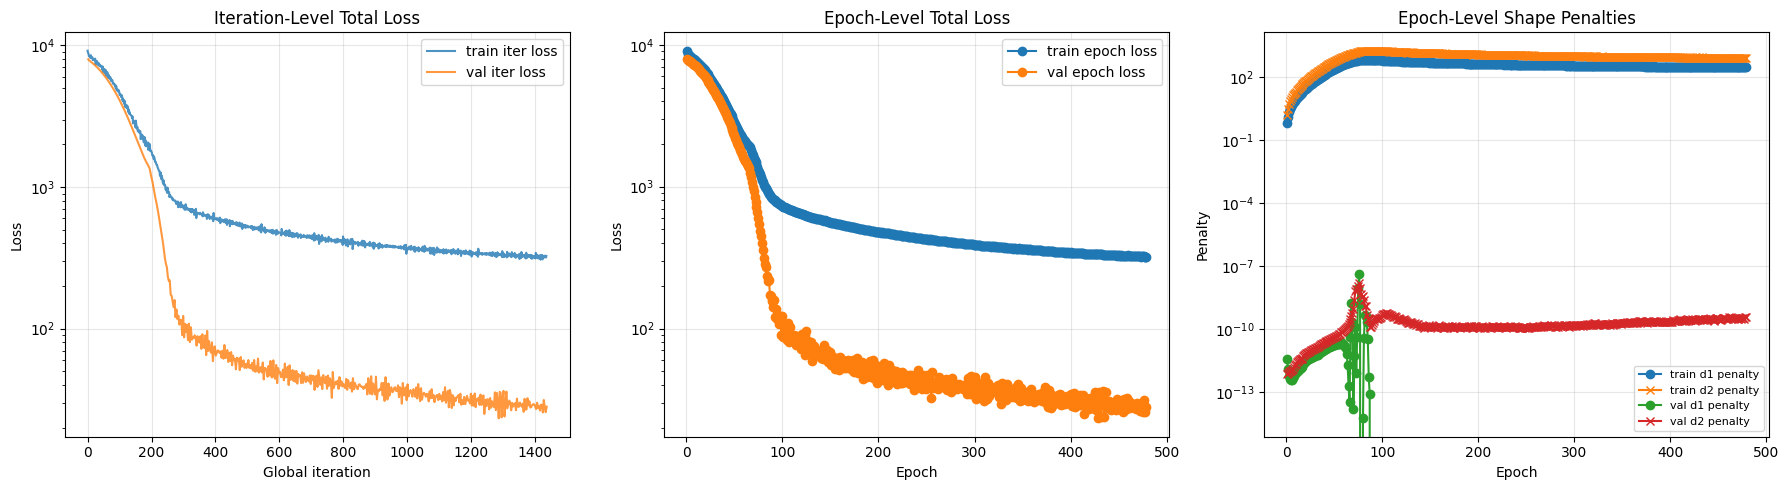

 - C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\runs_mlp\stage1_median_penetration_20260306_172838\loss_curves.png


In [261]:
# -------------------------------------------------------------------------
# Plot loss curves
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Iteration-level total loss
for split, g in df_iter_history.groupby("split"):
    axes[0].semilogy(g["global_iter"].to_numpy(), g["loss"].to_numpy(), label=f"{split} iter loss", alpha=0.8)
axes[0].set_title("Iteration-Level Total Loss")
axes[0].set_xlabel("Global iteration")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Epoch-level total loss
for split, g in df_epoch_history.groupby("split"):
    axes[1].semilogy(g["epoch"].to_numpy(), g["loss"].to_numpy(), marker="o", label=f"{split} epoch loss")
axes[1].set_title("Epoch-Level Total Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Epoch-level physics penalties
for split, g in df_epoch_history.groupby("split"):
    axes[2].semilogy(g["epoch"].to_numpy(), g["d1_penalty"].to_numpy(), marker="o", label=f"{split} d1 penalty")
    axes[2].semilogy(g["epoch"].to_numpy(), g["d2_penalty"].to_numpy(), marker="x", label=f"{split} d2 penalty")
axes[2].set_title("Epoch-Level Shape Penalties")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Penalty")
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=8)

plt.tight_layout()
fig_path = run_dir / "loss_curves.png"
plt.savefig(fig_path, dpi=160)
plt.show()
print(" -", fig_path)


Training loss > Validation loss, possibly due to the following reasons:

1. There are regularization techniques introduced during training, particularly dropout (Randomly shutdown *50%* of all neurons to force all neurons learn).

2. Training dataset is more difficult (randomly splitting (by test point) definitely puts more extreme working conditions in the training set)

3. Training loss contains pentalty terms: dS/dt > 0, dS/dt <= 0 after *0.5 ms* (set)

## Toy Inference Module (Manual Physical Inputs)

Use this section to manually input **unscaled physical values**, apply the same feature scaling used in Stage-1,
scan time from `0` to `5 ms`, and plot predicted penetration using the model's first output (`mu`).


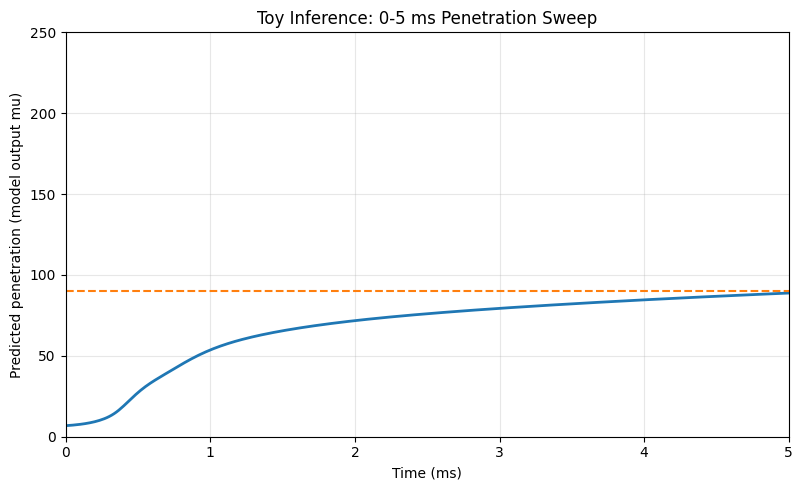

Toy inference completed with feature shape: (300, 9)
Expected feature dimension: 9


In [265]:
# -------------------------------------------------------------------------
# Toy inference: manual physical input -> scaled features -> 0~5 ms sweep
# -------------------------------------------------------------------------

# 1) Manual raw physical inputs (before scaling)
toy_raw = {
    "tilt_angle_radian": float(np.deg2rad(20.0)), # Umbrella angle 140 deg
    "plumes": 10.0,
    "diameter_mm": 0.355,
    "injection_duration_us": 700.0,
    "injection_pressure_bar": 2000.0,
    "chamber_pressure_bar": 35.0,
    "control_backpressure_bar": 4.0,
}

# 2) Time sweep setup
toy_n_points = 300
toy_time_ms = np.linspace(0.0, 5.0, toy_n_points, dtype=np.float32)


def _zscore_from_state(value: float, z_col: str, scaler_state_dict: dict) -> float:
    stats = scaler_state_dict["zscore"][z_col]
    return (float(value) - float(stats["mean"])) / (float(stats["std"]) + 1e-12)


def build_toy_feature_matrix(raw: dict, time_ms: np.ndarray, scaler_state_dict: dict) -> np.ndarray:
    # Pressure-derived raw terms
    p_inj = float(raw["injection_pressure_bar"])
    p_ch = float(raw["chamber_pressure_bar"])
    delta_p = max(p_inj - p_ch, 1e-6)

    log_p_inj = np.log(p_inj)
    log_p_ch = np.log(max(p_ch, 1e-6))
    log_delta_p = np.log(delta_p)

    # Static scaled terms
    tilt_z = _zscore_from_state(raw["tilt_angle_radian"], "tilt_angle_radian_z", scaler_state_dict)
    plumes_z = _zscore_from_state(raw["plumes"], "plumes_z", scaler_state_dict)
    diameter_z = _zscore_from_state(raw["diameter_mm"], "diameter_mm_z", scaler_state_dict)
    inj_dur_z = _zscore_from_state(raw["injection_duration_us"], "injection_duration_us_z", scaler_state_dict)

    log_p_inj_z = _zscore_from_state(log_p_inj, "log_injection_pressure_bar_z", scaler_state_dict)
    log_p_ch_z = _zscore_from_state(log_p_ch, "log_chamber_pressure_bar_z", scaler_state_dict)
    log_delta_p_z = _zscore_from_state(log_delta_p, "log_delta_pressure_bar_z", scaler_state_dict)
    cb_z = _zscore_from_state(raw["control_backpressure_bar"], "control_backpressure_bar_z", scaler_state_dict)

    time_norm = np.clip(time_ms, scaler_state_dict["time"]["min_ms"], scaler_state_dict["time"]["max_ms"]) / float(
        scaler_state_dict["time"]["max_ms"] - scaler_state_dict["time"]["min_ms"]
    )

    features = np.column_stack(
        [
            time_norm,
            np.full_like(time_norm, tilt_z, dtype=np.float32),
            np.full_like(time_norm, plumes_z, dtype=np.float32),
            np.full_like(time_norm, diameter_z, dtype=np.float32),
            np.full_like(time_norm, inj_dur_z, dtype=np.float32),
            np.full_like(time_norm, log_p_inj_z, dtype=np.float32),
            np.full_like(time_norm, log_p_ch_z, dtype=np.float32),
            np.full_like(time_norm, log_delta_p_z, dtype=np.float32),
            np.full_like(time_norm, cb_z, dtype=np.float32),
        ]
    ).astype(np.float32)

    return features


# 3) Resolve model
if "model_stage1" not in globals():
    model_stage1 = build_model(CONFIG)
    if "run_dir" in globals() and (Path(run_dir) / "best_model_stage1.pt").exists():
        state = torch.load(Path(run_dir) / "best_model_stage1.pt", map_location=CONFIG["device"])
        model_stage1.load_state_dict(state)
        print("Loaded checkpoint from current run_dir")
    else:
        print("Warning: model_stage1 not found and no checkpoint auto-loaded. Predictions use current random weights.")

model_stage1.eval()

# 4) Build features and run inference
toy_features_np = build_toy_feature_matrix(toy_raw, toy_time_ms, scaler_state)
toy_features = torch.as_tensor(toy_features_np, dtype=torch.float32, device=CONFIG["device"])

with torch.no_grad():
    toy_out = model_stage1(toy_features)
    toy_mu, toy_log_var = split_mu_logvar(toy_out)

toy_mu_np = toy_mu.detach().cpu().numpy().reshape(-1)

# 5) Plot penetration mean (first output)
plt.figure(figsize=(8, 5))
plt.plot(toy_time_ms, toy_mu_np, linewidth=2)
plt.plot(toy_time_ms, 90*np.ones_like(toy_time_ms), linestyle="--")
plt.xlabel("Time (ms)")
plt.ylabel("Predicted penetration (model output mu)")
plt.title("Toy Inference: 0-5 ms Penetration Sweep")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0, 250)
plt.xlim(0, 5)
plt.show()

print("Toy inference completed with feature shape:", toy_features_np.shape)
print("Expected feature dimension:", len(FEATURE_COLUMNS))
